#### Purpose of This Code

**This script:**
- Generates a synthetic 2D dataset (classification example).
- Trains a multi-layer neural network (MLPClassifier) to classify the data.
- Evaluates performance (accuracy, misclassified points).
- Plots the decision boundary and highlights misclassifications.

It’s a great demonstration of how a neural network learns nonlinear boundaries for classification

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_circles

- numpy → numerical operations
- pandas → data manipulation (not used here, but included)
- matplotlib → plotting
- Normalize, ListedColormap → handle color scales in plots
- MLPClassifier → multi-layer perceptron (neural network)
- train_test_split → split dataset into training/testing subsets
- make_classification, make_moons, make_circles → generate sample datasets

#### 2️⃣ Create or Load Data

In [6]:
X, y = make_classification(n_samples=100, n_features=2,
                           n_redundant=0, n_informative=2,
                           random_state=2, n_clusters_per_class=1,
                           flip_y=0.3)

#X, y = make_moons(n_samples = 100, noise=0.4,random_state=0)
#X, y = make_circles(n_samples = 400, noise=0.2, factor=0.5, random_state=1)

- make_classification creates a synthetic dataset:
    - n_samples=100 → 100 points
    - n_features=2 → two input features
    - n_redundant=0, n_informative=2 → both features carry useful information
    - flip_y=0.3 → 30% of labels are randomly flipped (adds noise)
    - random_state=2 → ensures reproducibility

🧠 This means we’re generating a noisy 2D dataset — some points don’t fit perfectly into their class — to test how robust our neural network is.

#### 3️⃣ Visualize the Raw Data

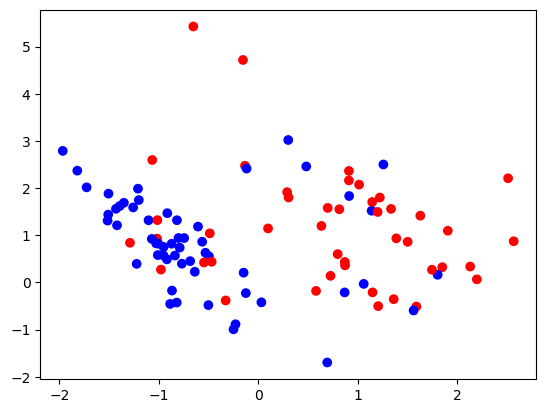

In [7]:
fig0, ax0 = plt.subplots()
nm = Normalize(vmin=0, vmax=1)
cm = ListedColormap(["blue", "red"])
m = ['o', 'x']
ax0.scatter(X[:, 0], X[:, 1], c=y, cmap=cm, norm=nm)
#fig0.savefig('NN_initial_plot.png')


#### 4️⃣ Split into Training and Testing Sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=0)

In [9]:
mlp = MLPClassifier(hidden_layer_sizes=(50,100,50),
                    activation="tanh", random_state=1, max_iter=2000)
mlp.fit(X_train, y_train)


MLPClassifier(activation='tanh', hidden_layer_sizes=(50, 100, 50),
              max_iter=2000, random_state=1)

#### Defines an MLP (Multi-Layer Perceptron) with:

**Hidden layers:** (50, 100, 50)
 - → three layers with 50, 100, and 50 neurons each.

**Activation:** "tanh"
 - → hyperbolic tangent activation, allows non-linear boundaries.

max_iter=2000
 - → train until convergence (up to 2000 iterations).

🧠 This is now a deep neural network, unlike the previous example (which had no hidden layers).

#### 6️⃣ Evaluate Performance

In [10]:
print('Our Accuracy is %.2f' % mlp.score(X_test, y_test))
print('Number of mislabeled points out of a total %d points : %d'
      % (X_test.shape[0], (y_test != mlp.predict(X_test)).sum()))

Our Accuracy is 0.79
Number of mislabeled points out of a total 34 points : 7


#### 7️⃣ Visualize the Decision Boundary

Misclassified Points:
 [[ 1.05891574 -0.02984642]
 [ 1.80228789  0.1624976 ]
 [ 0.57936765 -0.17841637]
 [-1.01918239  0.9304136 ]
 [ 1.13845568  1.5207657 ]
 [-0.32922076 -0.38114073]
 [ 1.20449563 -0.50069527]] [0 0 1 1 0 1 1]


Text(0, 0.5, 'X2')

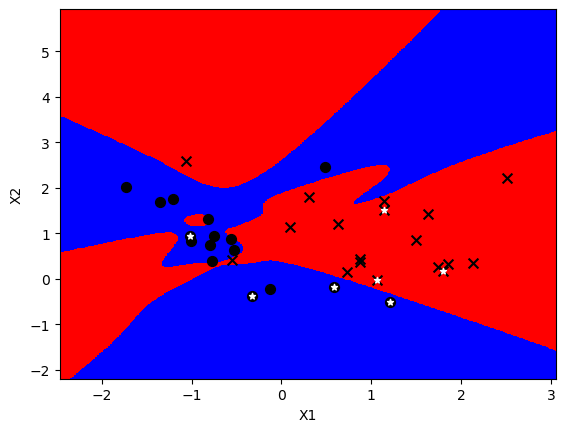

In [11]:
fig, ax = plt.subplots()
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))

#(b) Predict over the grid
Z = mlp.predict(np.column_stack([xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

#(c) Draw the Decision Regions
ax.contourf(xx, yy, Z, cmap=cm, norm=nm)

#(d) Plot the Test Data Points
for i in range(len(X_test)):
    ax.scatter(X_test[i,0], X_test[i,1],
               marker=m[mlp.predict(X_test)[i]],
               c='black', s=50)

#(e) Identify and Highlight Misclassified Points
mis_ind = np.where(y_test != mlp.predict(X_test))[0]
print('Misclassified Points:\n', X_test[mis_ind], y_test[mis_ind])
ax.scatter(X_test[mis_ind,0], X_test[mis_ind,1],marker='*', color='white', s=20)

#(f) Final Labels and Save
ax.set_xlabel('X1')
ax.set_ylabel('X2')
#fig.savefig('NN_plot.png')


### What the Code Demonstrates

- **Data Generation:** Creates a 2D dataset (either linear or nonlinear).
- **Model Training:** Uses a multi-layer perceptron (neural net) with nonlinear activation (tanh).
- **Testing:** Splits into train/test sets and evaluates accuracy.
- **Visualization:** Shows how the neural network partitions the space into decision regions.
- **Error Analysis:** Highlights which points are misclassified.